Dataset Shape: (101, 18)

First 5 Rows:
  animal name  hair  feathers  eggs  milk  airborne  aquatic  predator  \
0    aardvark     1         0     0     1         0        0         1   
1    antelope     1         0     0     1         0        0         0   
2        bass     0         0     1     0         0        1         1   
3        bear     1         0     0     1         0        0         1   
4        boar     1         0     0     1         0        0         1   

   toothed  backbone  breathes  venomous  fins  legs  tail  domestic  catsize  \
0        1         1         1         0     0     4     0         0        1   
1        1         1         1         0     0     4     1         0        1   
2        1         1         0         0     1     0     1         0        0   
3        1         1         1         0     0     4     0         0        1   
4        1         1         1         0     0     4     1         0        1   

   type  
0     1  
1     1 

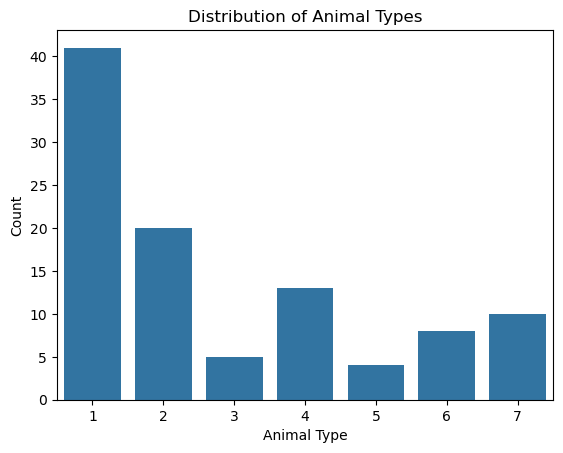

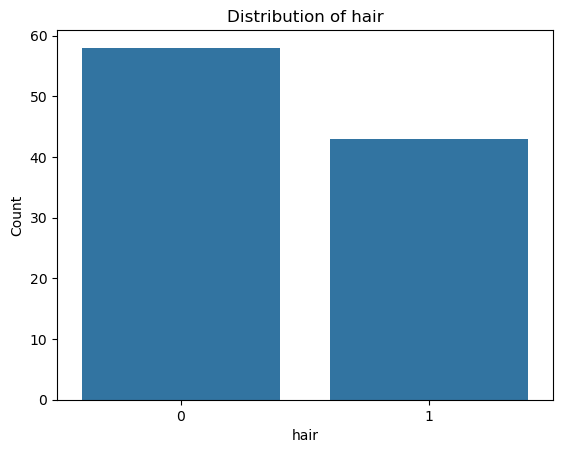

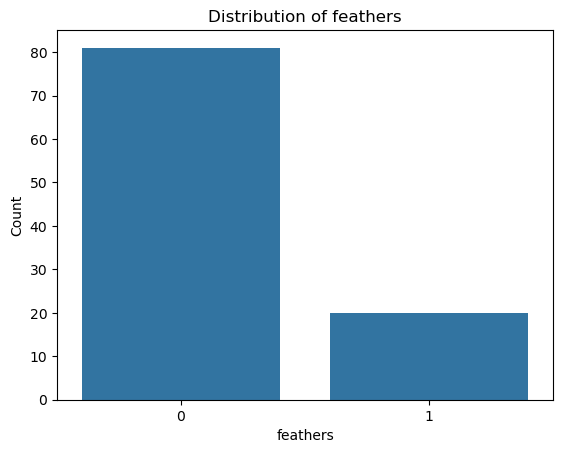

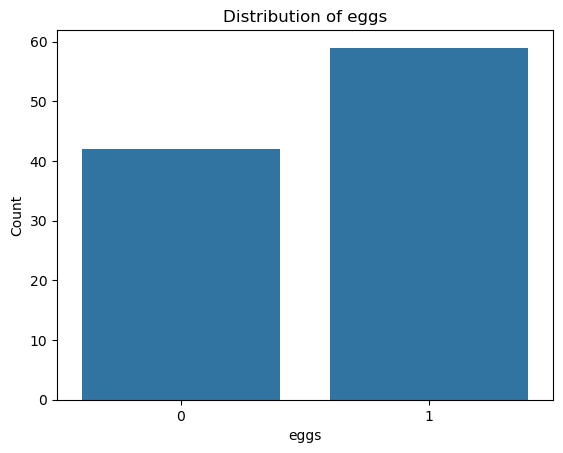

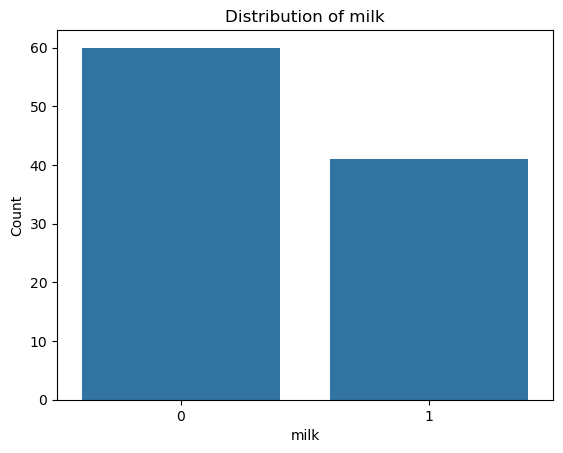

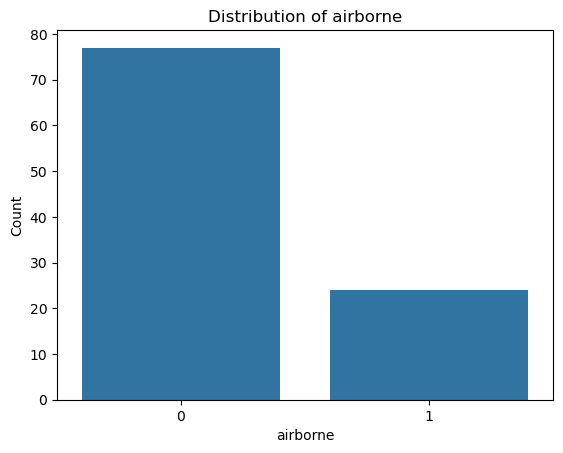

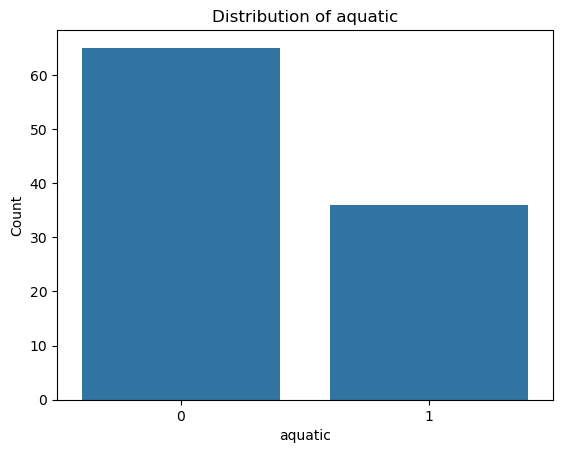

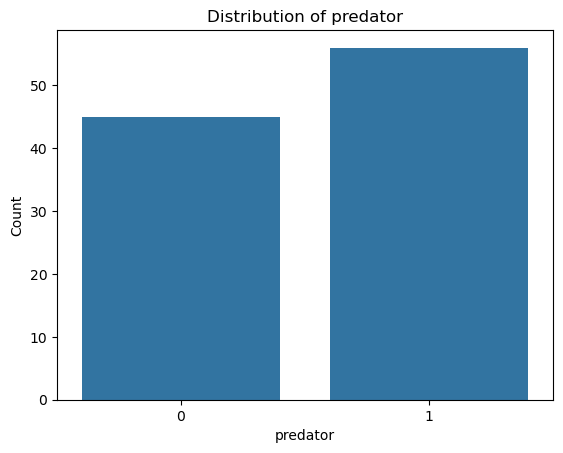

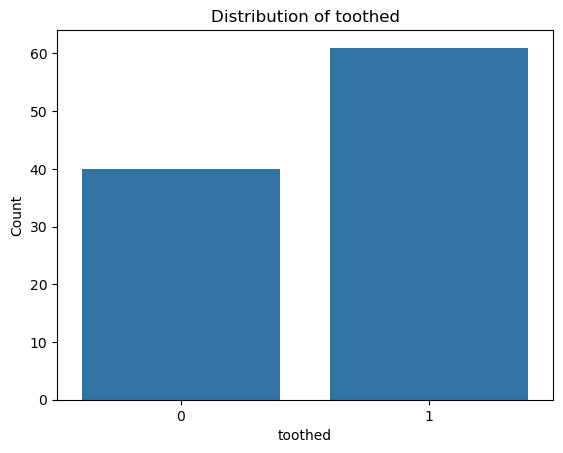

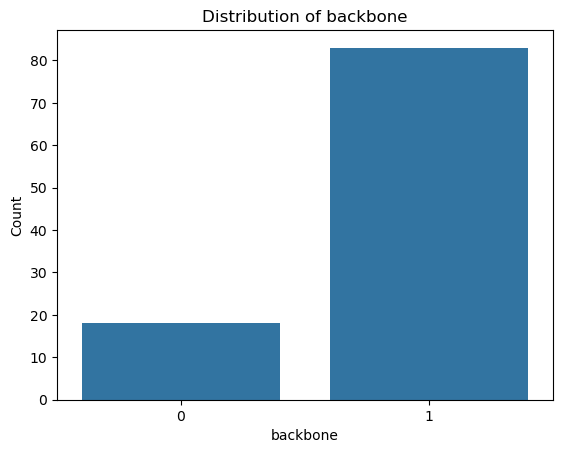

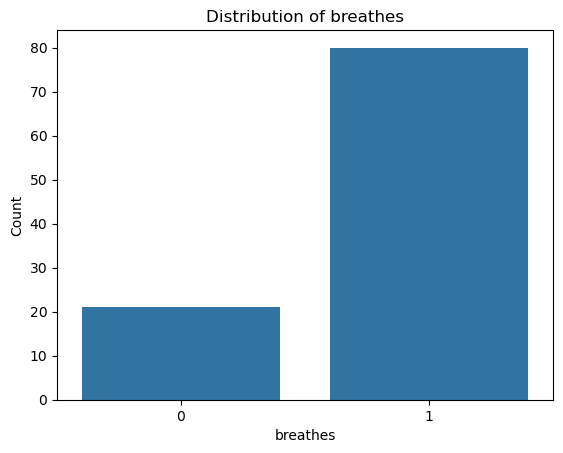

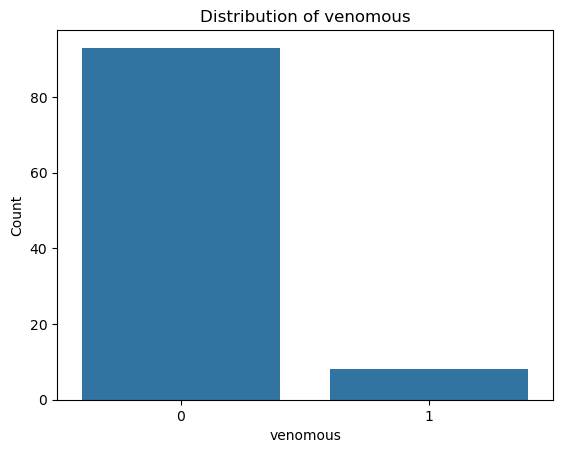

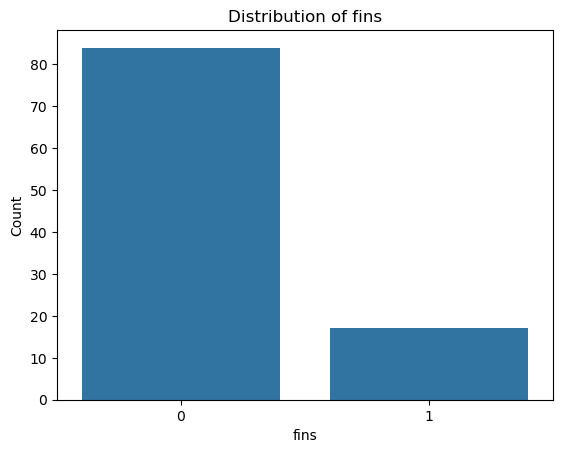

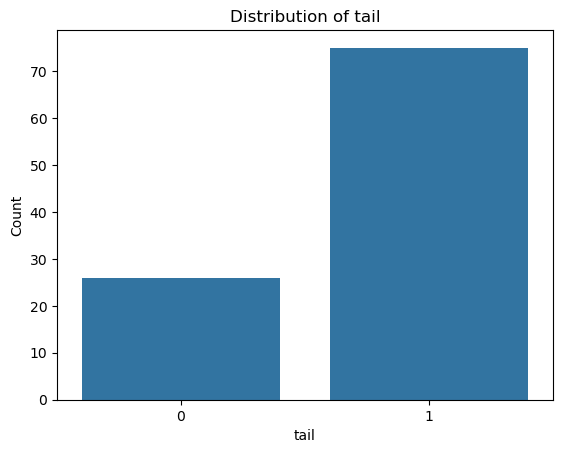

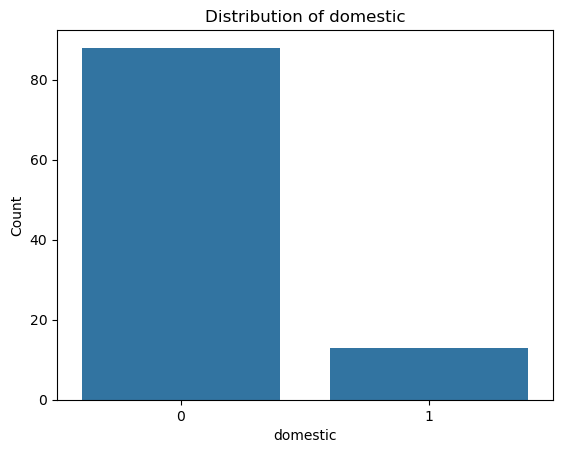

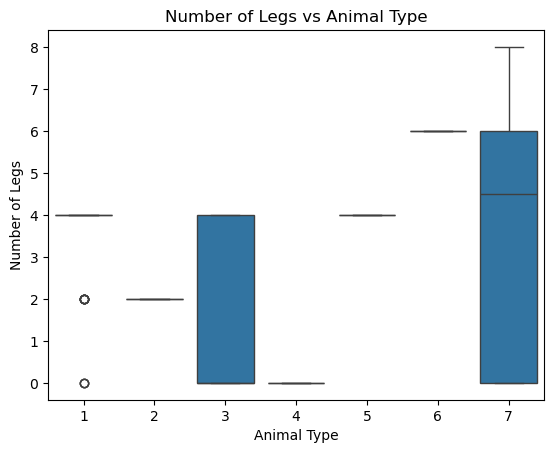

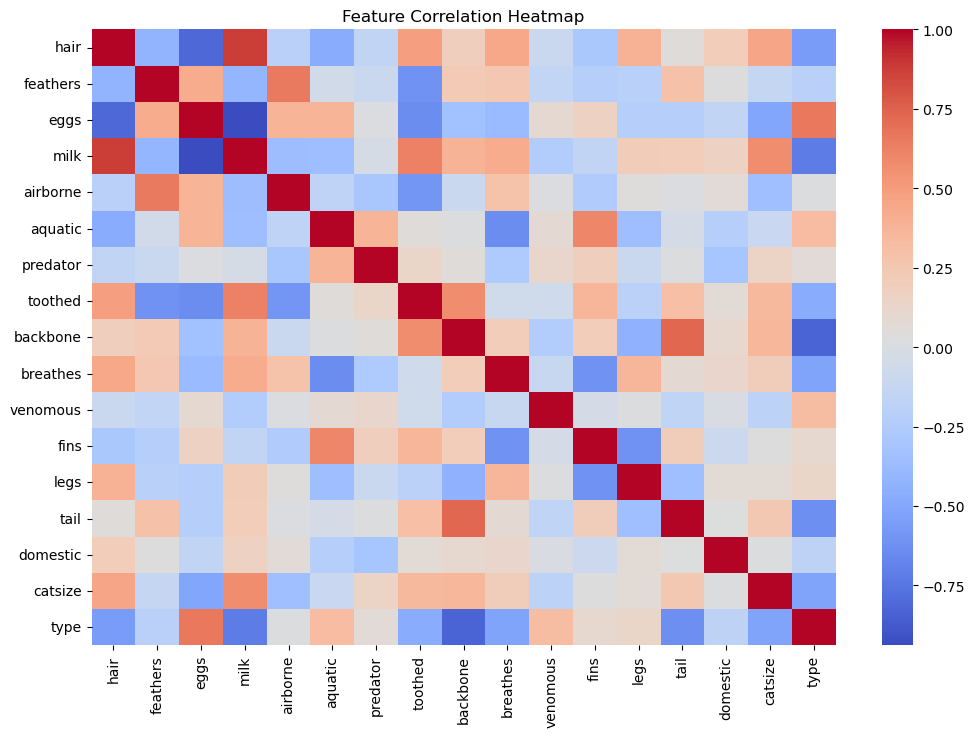

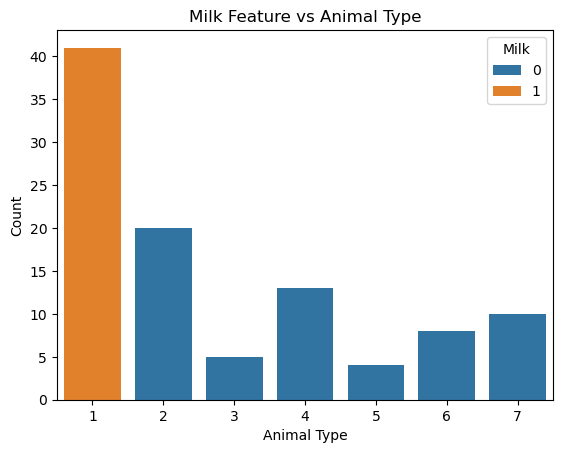

In [3]:
#1. Analyse the data using the visualizations

#IMPORT LIBRARIES
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

#LOAD DATASET
# Update path if required
df = pd.read_csv("Zoo[1].csv")

#BASIC DATA CHECK
print("Dataset Shape:", df.shape)
print("\nFirst 5 Rows:")
print(df.head())

print("\nDataset Info:")
print(df.info())

#1. CLASS DISTRIBUTION 
plt.figure()
sns.countplot(x="type", data=df)
plt.title("Distribution of Animal Types")
plt.xlabel("Animal Type")
plt.ylabel("Count")
plt.show()

# 2. FEATURE DISTRIBUTION (BINARY FEATURES)
binary_features = [
    "hair", "feathers", "eggs", "milk", "airborne",
    "aquatic", "predator", "toothed", "backbone",
    "breathes", "venomous", "fins", "tail", "domestic"
]

for feature in binary_features:
    plt.figure()
    sns.countplot(x=feature, data=df)
    plt.title(f"Distribution of {feature}")
    plt.xlabel(feature)
    plt.ylabel("Count")
    plt.show()

#3. LEGS vs ANIMAL TYPE
plt.figure()
sns.boxplot(x="type", y="legs", data=df)
plt.title("Number of Legs vs Animal Type")
plt.xlabel("Animal Type")
plt.ylabel("Number of Legs")
plt.show()

#4. FEATURE CORRELATION HEATMAP (FIXED)
# Remove non-numeric columns like animal_name
numeric_df = df.select_dtypes(include=["int64", "float64"])

plt.figure(figsize=(12, 8))
sns.heatmap(numeric_df.corr(), cmap="coolwarm")
plt.title("Feature Correlation Heatmap")
plt.show()

#5. MILK FEATURE vs ANIMAL TYPE
plt.figure()
sns.countplot(x="type", hue="milk", data=df)
plt.title("Milk Feature vs Animal Type")
plt.xlabel("Animal Type")
plt.ylabel("Count")
plt.legend(title="Milk")
plt.show()




Initial Dataset Shape: (101, 18)

Column Names:
Index(['animal name', 'hair', 'feathers', 'eggs', 'milk', 'airborne',
       'aquatic', 'predator', 'toothed', 'backbone', 'breathes', 'venomous',
       'fins', 'legs', 'tail', 'domestic', 'catsize', 'type'],
      dtype='object')

Missing Values in Each Column:
animal name    0
hair           0
feathers       0
eggs           0
milk           0
airborne       0
aquatic        0
predator       0
toothed        0
backbone       0
breathes       0
venomous       0
fins           0
legs           0
tail           0
domestic       0
catsize        0
type           0
dtype: int64

✔ No missing values found. No imputation required.


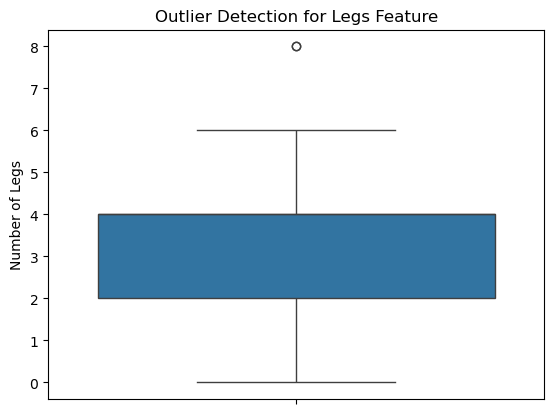


✔ Outlier Analysis:
Extreme values are biologically valid and retained.

Final Dataset Shape: (101, 18)

Final Preprocessed Dataset (First 5 Rows):
  animal name  hair  feathers  eggs  milk  airborne  aquatic  predator  \
0    aardvark     1         0     0     1         0        0         1   
1    antelope     1         0     0     1         0        0         0   
2        bass     0         0     1     0         0        1         1   
3        bear     1         0     0     1         0        0         1   
4        boar     1         0     0     1         0        0         1   

   toothed  backbone  breathes  venomous  fins  legs  tail  domestic  catsize  \
0        1         1         1         0     0     4     0         0        1   
1        1         1         1         0     0     4     1         0        1   
2        1         1         0         0     1     0     1         0        0   
3        1         1         1         0     0     4     0         0        1   
4

In [5]:
#2. Preprocess the data by handling missing values & Outliers, if any.

# IMPORT LIBRARIES
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# LOAD DATASET 
df = pd.read_csv("Zoo[1].csv")   # Update path if needed

print("Initial Dataset Shape:", df.shape)
print("\nColumn Names:")
print(df.columns)

# STEP 1: CHECK & HANDLE MISSING VALUES

print("\nMissing Values in Each Column:")
print(df.isnull().sum())

print("\n✔ No missing values found. No imputation required.")


# STEP 2: OUTLIER DETECTION

# Only numerical feature with variation is 'legs'
plt.figure()
sns.boxplot(y=df["legs"])
plt.title("Outlier Detection for Legs Feature")
plt.ylabel("Number of Legs")
plt.show()

print("\n✔ Outlier Analysis:")
print("Extreme values are biologically valid and retained.")


# STEP 3: DROP NON-USEFUL IDENTIFIER COLUMN (SAFE METHOD)

# Possible name columns in different Zoo dataset versions
possible_name_cols = ["animal_name", "animal", "name"]

for col in possible_name_cols:
    if col in df.columns:
        df = df.drop(columns=[col])
        print(f"✔ Dropped non-useful column: {col}")


# FINAL PREPROCESSED DATASET

print("\nFinal Dataset Shape:", df.shape)
print("\nFinal Preprocessed Dataset (First 5 Rows):")
print(df.head())



In [6]:
#3. Split the dataset into training and testing sets (80% training, 20% testing).

#IMPORT REQUIRED LIBRARY
from sklearn.model_selection import train_test_split

# SEPARATE FEATURES AND TARGET
X = df.drop(columns=["type"])   # Features
y = df["type"]                  # Target variable

print("Features shape:", X.shape)
print("Target shape:", y.shape)

#SPLIT THE DATASET
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.20,      # 20% test data
    train_size=0.80,     # 80% training data
    random_state=42,
    stratify=y           # Maintains class distribution
)

#DISPLAY SPLIT SHAPES
print("\nTraining set shape:")
print("X_train:", X_train.shape)
print("y_train:", y_train.shape)

print("\nTesting set shape:")
print("X_test:", X_test.shape)
print("y_test:", y_test.shape)


Features shape: (101, 17)
Target shape: (101,)

Training set shape:
X_train: (80, 17)
y_train: (80,)

Testing set shape:
X_test: (21, 17)
y_test: (21,)


In [8]:
#4. Implement the K-Nearest Neighbours algorithm using a machine learning library like scikit-learn On training dataset

#IMPORT LIBRARIES 
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import StandardScaler

#REMOVE NON-NUMERIC COLUMNS
# Keep only numeric columns
X_train_numeric = X_train.select_dtypes(include=["int64", "float64"])
X_test_numeric  = X_test.select_dtypes(include=["int64", "float64"])

print("✔ Non-numeric columns removed")
print("Training features shape:", X_train_numeric.shape)

#FEATURE SCALING (VERY IMPORTANT FOR KNN)
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train_numeric)
X_test_scaled = scaler.transform(X_test_numeric)

print("✔ Feature scaling completed")

# CREATE KNN MODEL
knn = KNeighborsClassifier(
    n_neighbors=5,
    metric="euclidean"
)

#TRAIN THE MODEL
knn.fit(X_train_scaled, y_train)

print("✔ KNN model trained successfully on training dataset")


✔ Non-numeric columns removed
Training features shape: (80, 16)
✔ Feature scaling completed
✔ KNN model trained successfully on training dataset


In [9]:
#5. Choose an appropriate distance metric and value for K.

from sklearn.metrics import accuracy_score

k_values = range(1, 21)
accuracy_list = []

for k in k_values:
    knn = KNeighborsClassifier(
        n_neighbors=k,
        metric="euclidean"
    )
    knn.fit(X_train_scaled, y_train)
    y_pred = knn.predict(X_test_scaled)
    accuracy = accuracy_score(y_test, y_pred)
    accuracy_list.append(accuracy)

# Display accuracy for each K
for k, acc in zip(k_values, accuracy_list):
    print(f"K = {k} → Accuracy = {acc:.4f}")

# Best K
best_k = k_values[accuracy_list.index(max(accuracy_list))]
print("\n✔ Best K value:", best_k)


K = 1 → Accuracy = 1.0000
K = 2 → Accuracy = 1.0000
K = 3 → Accuracy = 1.0000
K = 4 → Accuracy = 1.0000
K = 5 → Accuracy = 1.0000
K = 6 → Accuracy = 0.9048
K = 7 → Accuracy = 1.0000
K = 8 → Accuracy = 1.0000
K = 9 → Accuracy = 0.9048
K = 10 → Accuracy = 0.9048
K = 11 → Accuracy = 0.9048
K = 12 → Accuracy = 0.9048
K = 13 → Accuracy = 0.9524
K = 14 → Accuracy = 0.9524
K = 15 → Accuracy = 0.9524
K = 16 → Accuracy = 0.9048
K = 17 → Accuracy = 0.9048
K = 18 → Accuracy = 0.9048
K = 19 → Accuracy = 0.9048
K = 20 → Accuracy = 0.9048

✔ Best K value: 1


In [11]:
#6. Evaluate the classifier's performance on the testing set using accuracy, precision, recall, and F1-score metrics.

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report
)

# Predictions
y_pred = knn.predict(X_test_scaled)

# Metrics (handle undefined cases safely)
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred, average='weighted', zero_division=0)
recall = recall_score(y_test, y_pred, average='weighted', zero_division=0)
f1 = f1_score(y_test, y_pred, average='weighted', zero_division=0)

# Print results
print("Model Performance on Testing Set:\n")
print(f"Accuracy  : {accuracy:.4f}")
print(f"Precision : {precision:.4f}")
print(f"Recall    : {recall:.4f}")
print(f"F1-score  : {f1:.4f}")

# Detailed report
print("\nClassification Report:")
print(classification_report(y_test, y_pred, zero_division=0))


Model Performance on Testing Set:

Accuracy  : 0.9048
Precision : 0.8349
Recall    : 0.9048
F1-score  : 0.8646

Classification Report:
              precision    recall  f1-score   support

           1       1.00      1.00      1.00         8
           2       0.80      1.00      0.89         4
           3       0.00      0.00      0.00         1
           4       1.00      1.00      1.00         3
           5       0.00      0.00      0.00         1
           6       1.00      1.00      1.00         2
           7       0.67      1.00      0.80         2

    accuracy                           0.90        21
   macro avg       0.64      0.71      0.67        21
weighted avg       0.83      0.90      0.86        21



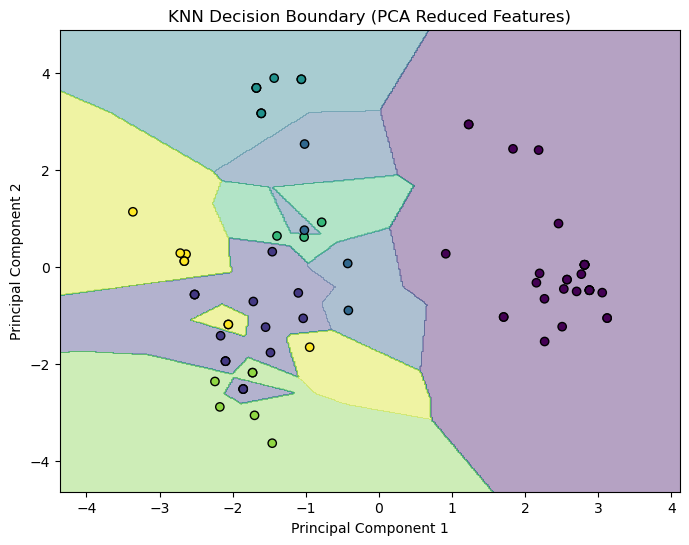

In [12]:
#7. Visualize the decision boundaries of the classifier.

import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.neighbors import KNeighborsClassifier

#APPLY PCA (2D)
pca = PCA(n_components=2)
X_train_pca = pca.fit_transform(X_train_scaled)
X_test_pca = pca.transform(X_test_scaled)

#TRAIN KNN ON PCA DATA
knn_pca = KNeighborsClassifier(
    n_neighbors=best_k,      # use optimal K from Task-5
    metric="euclidean"
)
knn_pca.fit(X_train_pca, y_train)

#CREATE MESH GRID
x_min, x_max = X_train_pca[:, 0].min() - 1, X_train_pca[:, 0].max() + 1
y_min, y_max = X_train_pca[:, 1].min() - 1, X_train_pca[:, 1].max() + 1

xx, yy = np.meshgrid(
    np.arange(x_min, x_max, 0.02),
    np.arange(y_min, y_max, 0.02)
)

#PREDICT ON GRID
Z = knn_pca.predict(np.c_[xx.ravel(), yy.ravel()])
Z = Z.reshape(xx.shape)

#PLOT DECISION BOUNDARY
plt.figure(figsize=(8, 6))
plt.contourf(xx, yy, Z, alpha=0.4)
plt.scatter(
    X_train_pca[:, 0],
    X_train_pca[:, 1],
    c=y_train,
    edgecolor="k"
)

plt.title("KNN Decision Boundary (PCA Reduced Features)")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.show()


In [ ]:
Interview Questions:

1. What are the key hyperparameters in KNN?

In K-Nearest Neighbors (KNN), the key hyperparameters that significantly affect model performance are the number of neighbors (k), the distance metric, 
and the weighting strategy. The k value determines how many nearest data points are considered when making a prediction; a small k can make the model 
sensitive to noise, while a large k may oversmooth the decision boundary. The distance metric (such as Euclidean, Manhattan, or Minkowski) defines how 
similarity is measured between data points, and choosing the right metric is important based on the nature of the features. The weighting strategy 
controls how neighbors influence the prediction—either all neighbors contribute equally or closer neighbors are given more importance using distance 
based weights. Additionally, feature scaling is crucial in KNN because it relies on distance calculations; features with larger scales can dominate the 
distance measure if not standardized. These hyperparameters must be tuned carefully to achieve the best accuracy and generalization in KNN models.

2. What distance metrics can be used in KNN?

In KNN, several distance metrics can be used to measure similarity between data points, and the choice depends on the type of data and problem. The most 
common is Euclidean distance, which calculates the straight-line distance between two points and works well for continuous numerical features. Manhattan 
distance (or L1 distance) measures the sum of absolute differences and is useful when features are on different scales or when outliers are present. 
Minkowski distance is a generalized form that includes both Euclidean and Manhattan as special cases, allowing flexibility by adjusting the parameter p. 
For categorical or mixed-type data, Hamming distance counts the number of positions with different values and is suitable for binary or categorical 
features. Cosine similarity (often used as a distance metric by converting similarity to distance) measures the angle between vectors and is commonly 
used in text and high-dimensional data where magnitude is less important than direction. Choosing the right distance metric is important because KNN 
predictions rely entirely on how “closeness” is defined between samples.